# **INICIANDO AMBIENTE E VARIAVEIS LOCAIS**

In [ ]:
pip install pandas numpy matplotlib seaborn

In [2]:

import pandas as pd

url = "https://raw.githubusercontent.com/acorrea79/IASTTechChallenge/main/dataset_tratado.csv"

df = pd.read_csv(url)

# visualizar estrutura inicial
print(df.shape)
df.head()

(2500, 20)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_class
0,1,63,nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,neutro
1,2,20,sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,detrator
2,3,46,nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,detrator
3,4,52,centro-oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,detrator
4,5,56,norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,neutro


### Podemos gerar um gráfico com a distribuição do NPS, com ele esperamos buscar entender a concentração das notas onde:
### altas → experiência positiva
### muitos baixos → problema operacional

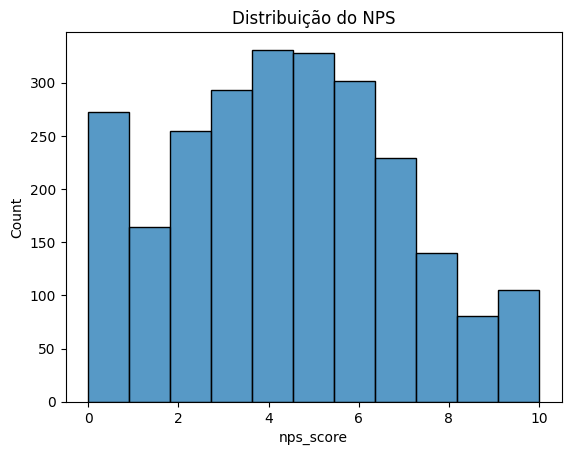

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["nps_score"], bins=11)
plt.title("Distribuição do NPS")
plt.show()

A distribuição do NPS apresenta maior concentração entre as notas 4 e 6, com baixa incidência de avaliações extremas (9–10). Esse padrão indica que a maior parte dos clientes se encontra em uma zona de neutralidade ou leve insatisfação, sem percepção clara de valor ou encantamento.

Do ponto de vista estratégico, observa-se um volume relevante de clientes classificados como passivos (7–8) e, principalmente, detratores (0–6), enquanto a base de promotores (9–10) é inferior ao desejado. Isso sugere que o desafio não está apenas na redução da insatisfação, mas principalmente na ausência de experiências que gerem diferenciação e fidelização.

Um ponto crítico é que pequenas melhorias na experiência do cliente têm potencial de gerar impacto significativo no NPS. Isso ocorre porque há uma concentração de clientes em faixas intermediárias (4–6), que são mais suscetíveis à conversão. A evolução desses clientes tende a ser mais eficiente do que a aquisição de novos promotores.

Como oportunidade de negócio, recomenda-se direcionar esforços para elevar avaliações na faixa de 5–6 para níveis de 7–8 ou 9, atuar de forma preventiva ao longo da jornada do cliente e desenvolver ações específicas voltadas para clientes próximos da satisfação plena.

### Podemos tambem, analisar a proporção dos clientes
### Com isso, buscamos entendenr a porcentagem com relação a classificação (quantidade x qualidade) onde :
### % de promotores = saúde da marca
### detratores = risco direto ao negócio

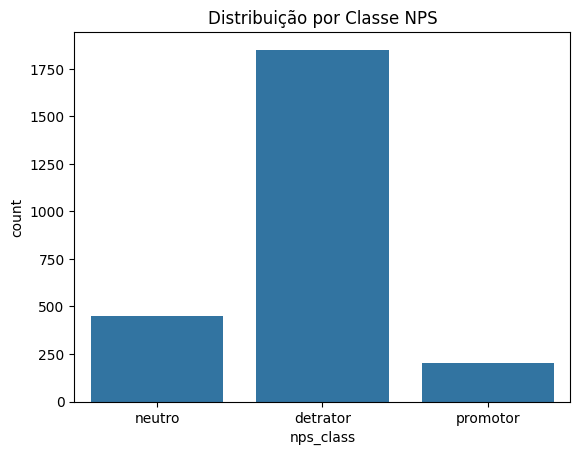

In [4]:
df["nps_class"].value_counts(normalize=True) * 100

sns.countplot(x="nps_class", data=df)
plt.title("Distribuição por Classe NPS")
plt.show()

A distribuição por classe de NPS evidencia uma forte concentração de clientes na categoria de detratores, enquanto os grupos de neutros e, principalmente, promotores apresentam volumes significativamente menores.

Esse cenário indica um nível elevado de insatisfação na base de clientes, com impacto direto na percepção da marca e no potencial de recomendação. A baixa representatividade de promotores reforça a ausência de experiências positivas consistentes.

Do ponto de vista estratégico, o principal problema não está apenas na conversão de neutros, mas na redução do volume de detratores. Isso sugere falhas relevantes na jornada do cliente, que estão gerando experiências negativas de forma recorrente.

Como implicação, torna-se prioritário identificar os principais drivers de insatisfação e atuar na sua correção. A redução de detratores tende a gerar impacto mais imediato no NPS do que ações focadas exclusivamente em conversão de neutros.

Como oportunidade de negócio, recomenda-se priorizar iniciativas de melhoria operacional, atuar preventivamente em pontos críticos da jornada e estruturar ações específicas para recuperação de clientes insatisfeitos.


### Agora, podemos analisar a Correlação com variáveis numéricas visando entender as variaveis que possuem maior correlação, a fim de facilitar analises futuras.

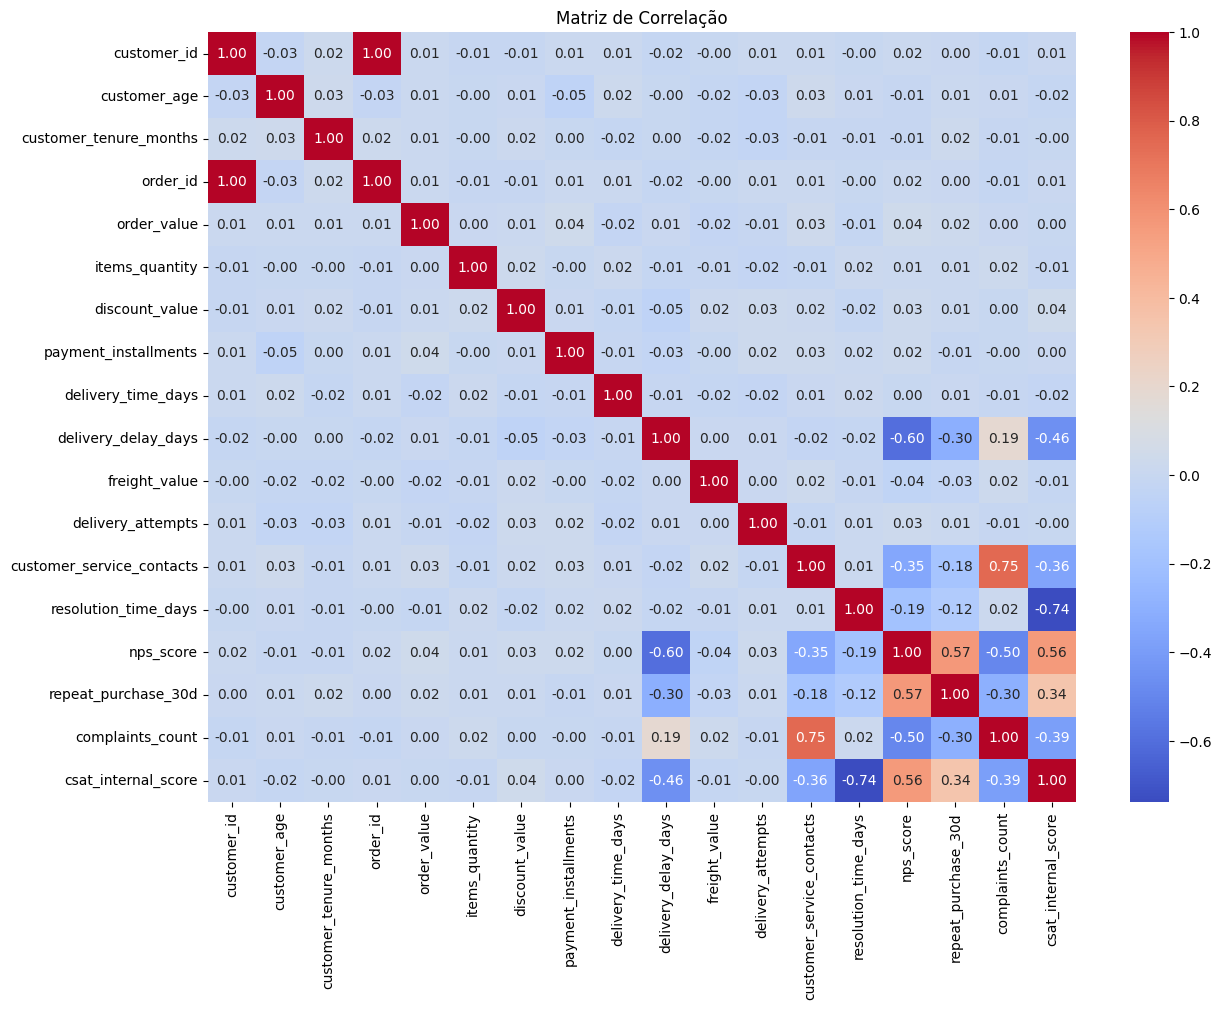

In [7]:
# seleciona apenas colunas numéricas
df_num = df.select_dtypes(include=['int64', 'float64'])

df_num.columns

corr = df_num.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

A matriz indica que a satisfação do cliente está mais relacionada à qualidade da entrega e do atendimento do que ao valor da compra, desconto, frete ou quantidade de itens.

O principal ponto de atenção é o atraso na entrega. Quanto maior o atraso, menor tende a ser a nota de recomendação, a satisfação e a chance de o cliente comprar novamente.

Outro fator importante é o atendimento ao cliente. Quando o cliente precisa entrar em contato muitas vezes, aumentam as reclamações e caem os indicadores de satisfação. Isso sugere que o atendimento está sendo acionado principalmente para resolver problemas na jornada.

Também se destaca o tempo de resolução. Quanto mais demorada a solução, maior o impacto negativo na satisfação do cliente.

Por outro lado, clientes com melhor nota de recomendação tendem a apresentar maior chance de recompra em 30 dias, mostrando que uma boa experiência favorece a fidelização.

## Agora realizaremos algumas correlações entre NPS e variaveis escolhidas com base no grafico acima, a fim de gerar insights para uma analise mais refinada


In [ ]:
aqui, podemos ver numericamente o resultado do grafico, facilitando a escolha das variaveis para a analise

In [8]:
corr_nps = corr["nps_score"].sort_values(ascending=False)

print(corr_nps)

nps_score                    1.000000
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
customer_id                  0.015162
order_id                     0.015162
items_quantity               0.011468
delivery_time_days           0.000925
customer_tenure_months      -0.009711
customer_age                -0.009936
freight_value               -0.041087
resolution_time_days        -0.191392
customer_service_contacts   -0.350845
complaints_count            -0.496800
delivery_delay_days         -0.597260
Name: nps_score, dtype: float64


Correlacionamos agora, Logística, Problemas e o NPS

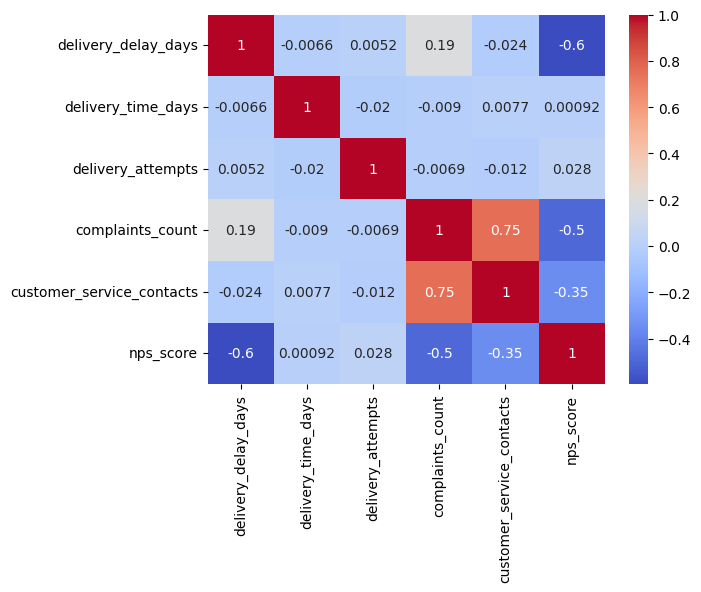

In [10]:
cols = [
    "delivery_delay_days",
    "delivery_time_days",
    "delivery_attempts",
    "complaints_count",
    "customer_service_contacts",
    "nps_score"
]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

Os maiores impactos no NPS estão relacionados aos atrasos na entrega, reclamações e necessidade de contato com o atendimento.

O principal destaque é o atraso na entrega (delivery_delay_days), que possui forte relação negativa com o NPS. Isso indica que, quanto maior o atraso, menor tende a ser a satisfação e a recomendação do cliente.

Outro ponto importante é a relação entre reclamações e contatos com atendimento, que apresentam forte conexão entre si. Na prática, isso mostra que clientes com problemas acabam acionando mais vezes o suporte da empresa.

As reclamações também impactam diretamente o NPS. Quanto maior a quantidade de reclamações, menor tende a ser a percepção positiva do cliente sobre a empresa.

Já o tempo normal de entrega e o número de tentativas de entrega apresentaram pouca influência direta no NPS, indicando que o maior problema não está no processo padrão, mas sim nos casos de atraso e falhas percebidas pelo cliente.

### Correlacionamos agora Atendimento , Resolução e Satisfação

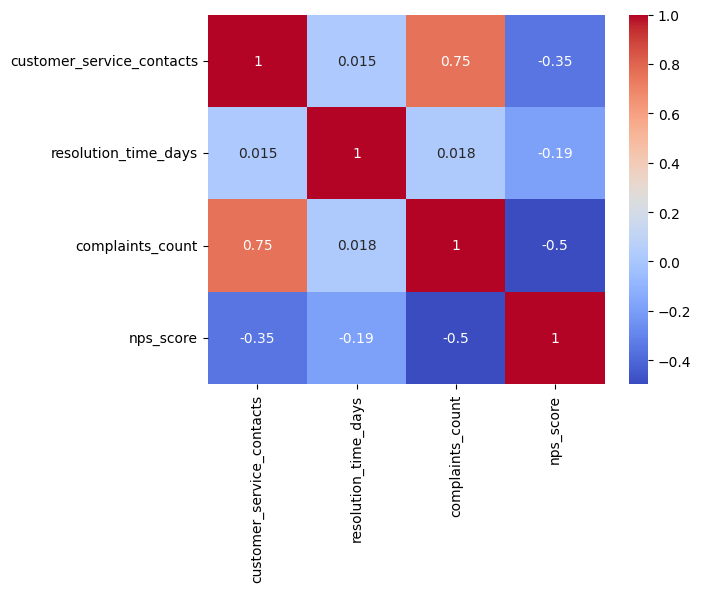

In [11]:
cols = [
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "nps_score"
]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

A satisfação do cliente está fortemente ligada à quantidade de reclamações e à necessidade de contato com o atendimento.

O principal destaque é a forte relação entre reclamações e contatos com atendimento. Isso indica que clientes com problemas acabam acionando mais vezes a empresa para buscar solução.

Também foi identificado que o aumento das reclamações reduz significativamente o NPS, mostrando que problemas não resolvidos impactam diretamente a percepção do cliente sobre a marca.

Os contatos com atendimento também apresentam impacto negativo na satisfação. Na prática, quanto mais o cliente precisa procurar suporte, menor tende a ser sua experiência positiva.

Já o tempo de resolução apresentou impacto menor do que o esperado, mas ainda assim demonstra que demoras na solução podem contribuir para queda na satisfação.

### Correlacionamos agora Logística e Atendimento

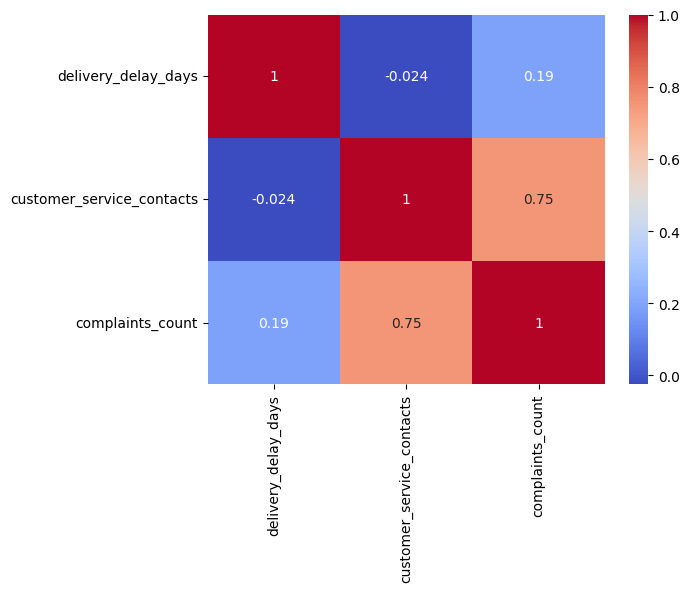

In [12]:
cols = [
    "delivery_delay_days",
    "customer_service_contacts",
    "complaints_count"
]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

Existe uma forte relação entre reclamações e contatos com o atendimento. Isso indica que, quando ocorrem problemas na experiência do cliente, há aumento significativo da procura pelo suporte da empresa.

Os atrasos na entrega também apresentam relação com o aumento das reclamações, embora em intensidade menor. Na prática, isso sugere que falhas logísticas contribuem diretamente para insatisfação e abertura de chamados.

Por outro lado, os atrasos não demonstraram ligação forte com a quantidade de contatos realizados ao atendimento. Isso pode indicar que parte dos clientes reclama diretamente pelos canais formais ou que outros fatores além da logística também influenciam o acionamento do suporte.

### Correlacionamos agora Preço e Experiência

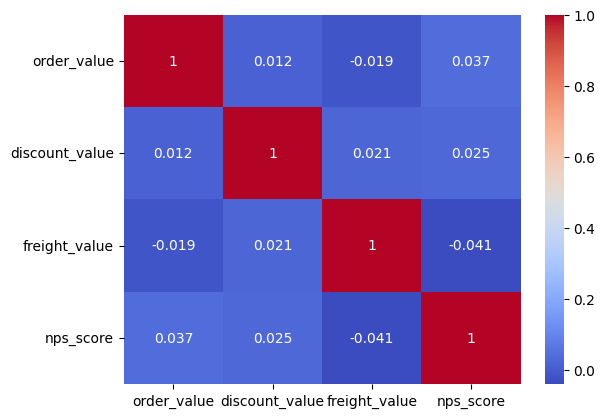

In [13]:
cols = [
    "order_value",
    "discount_value",
    "freight_value",
    "nps_score"
]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

Fatores financeiros, como valor do pedido, desconto e frete, tiveram pouca influência direta na satisfação do cliente.

O valor da compra e os descontos apresentaram relação muito baixa com o NPS, indicando que clientes satisfeitos não dependem apenas de preço menor ou promoções para recomendar a empresa.

O frete também demonstrou impacto reduzido na experiência geral, sugerindo que o cliente valoriza mais a qualidade da entrega e do atendimento do que apenas o custo do envio.

### Correlacionamos agora Satisfação e Recompra




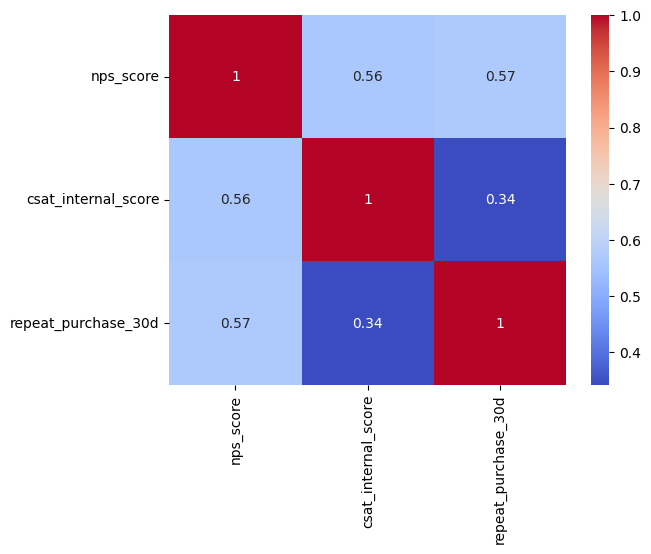

In [14]:
cols = [
    "nps_score",
    "csat_internal_score",
    "repeat_purchase_30d"
]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

Clientes mais satisfeitos tendem a comprar novamente e recomendar mais a empresa.

O NPS apresentou forte relação com a recompra em 30 dias, indicando que uma boa experiência aumenta significativamente a chance de fidelização do cliente.

Também foi observada uma relação positiva entre satisfação interna e recompra, embora em menor intensidade. Isso reforça que clientes satisfeitos possuem maior tendência de continuar consumindo os produtos ou serviços da empresa.

Além disso, a satisfação interna e o NPS apresentam comportamento semelhante, mostrando que ambos acompanham a percepção positiva do cliente em relação à experiência oferecida.

## Conclusão Geral da Análise

A análise consolidada demonstra que a experiência do cliente está muito mais ligada à qualidade operacional e ao atendimento do que a fatores financeiros, como preço, desconto ou valor da compra.

Os resultados mostram que os maiores impactos negativos na satisfação acontecem quando há atrasos na entrega, aumento de reclamações e necessidade frequente de contato com o atendimento. Esses fatores reduzem diretamente a percepção positiva do cliente e diminuem as chances de recomendação e recompra.

Entre todos os pontos analisados, o atraso na entrega aparece como um dos principais fatores de insatisfação. Quando o cliente recebe o pedido fora do prazo esperado, aumentam as reclamações, cresce a procura pelo suporte e ocorre queda significativa no NPS.

A análise também evidencia que clientes que precisam entrar em contato diversas vezes com o atendimento tendem a apresentar menor satisfação. Isso sugere que o suporte está sendo utilizado principalmente para resolver problemas operacionais, e não apenas como canal de relacionamento. Além disso, o volume de reclamações possui forte relação com o acionamento do atendimento, reforçando que falhas na jornada acabam gerando retrabalho e desgaste na experiência do cliente.

Outro ponto importante é o tempo de resolução dos problemas. Embora o impacto seja menor do que o atraso ou as reclamações, a demora na solução também contribui para redução da satisfação e piora da percepção sobre a empresa.

Por outro lado, os dados mostram um cenário muito positivo em relação à fidelização. Clientes satisfeitos possuem maior tendência de recomendar a empresa e realizar novas compras em curto prazo. O NPS apresentou forte relação com a recompra, demonstrando que melhorar a experiência do cliente gera impacto direto nos resultados comerciais.

A análise financeira também trouxe um resultado relevante: fatores como desconto, valor do pedido e frete tiveram pouca influência sobre satisfação e fidelização. Isso indica que o cliente valoriza mais uma experiência eficiente, rápida e sem problemas do que apenas preços menores ou promoções.

De forma geral, os dados mostram que a fidelização do cliente depende principalmente de:

Entregas dentro do prazo;
Redução de problemas operacionais;
Menor volume de reclamações;
Atendimento mais eficiente;
Resolução rápida no primeiro contato.

A empresa possui oportunidade clara de melhorar satisfação, retenção e recompra ao investir na eficiência logística e na qualidade do pós-venda. Mais do que competir por preço, os resultados indicam que o diferencial está em oferecer uma experiência confiável, simples e sem fricção para o cliente.